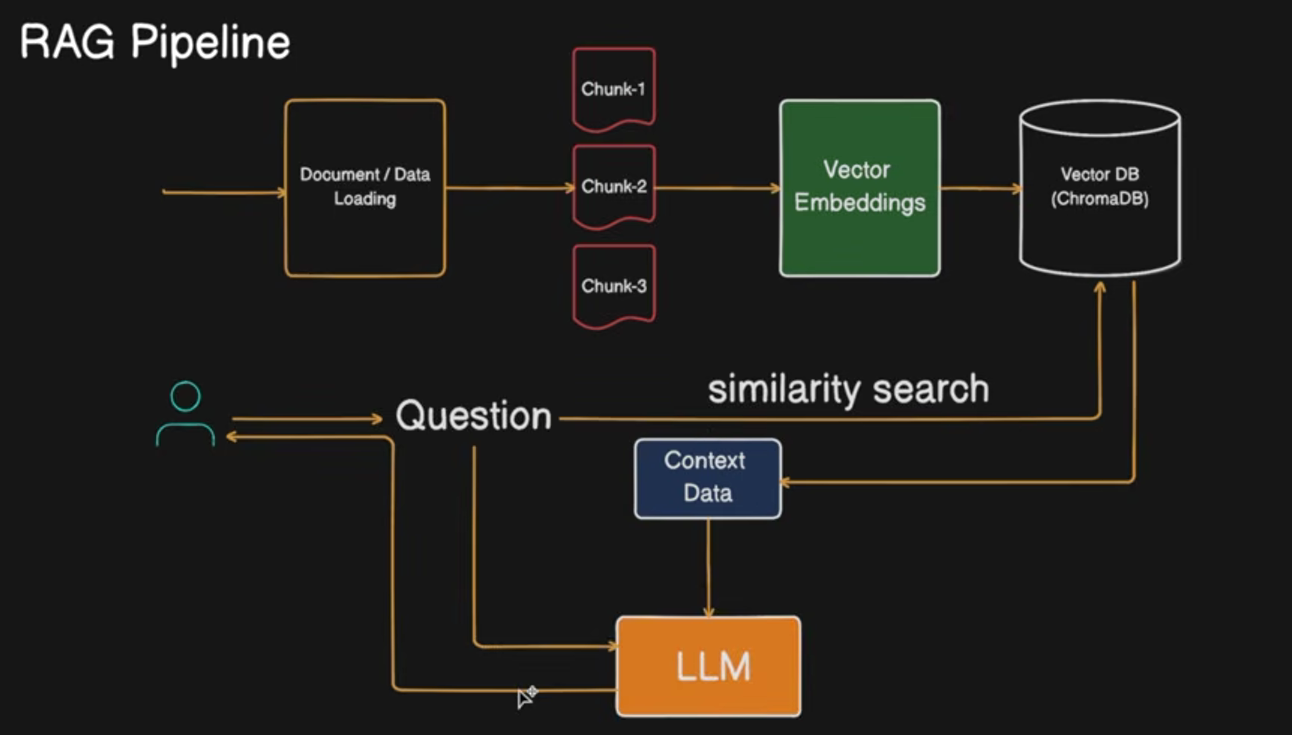

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [19]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI 
from langchain_chroma import Chroma
from langchain_core.prompts import PromptTemplate

In [33]:
loader = PyPDFLoader(
    "../data/medical_report.pdf",
    )
docs = loader.load()
len(docs)

9

In [34]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000 , chunk_overlap = 200)
splitted_data = splitter.split_documents(docs)
len(splitted_data)

26

In [35]:
embeddings = GoogleGenerativeAIEmbeddings(model = "gemini-embedding-2-preview")

In [36]:
vector_store = Chroma.from_documents(
    documents = splitted_data,
    embedding= embeddings
)

In [37]:
query = "Machine Learning and Data Science Content"
data = vector_store.similarity_search(query = query)

In [38]:
context = ""
for doc in data:
    context += doc.page_content + "\n"
    


In [39]:
llm  = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")

#Chain - Context_generate | prompt | llm | strparser

In [40]:
def get_context(query:str):
    data = vector_store.similarity_search(query = query)
    context = ""
    for doc in data:
        context += doc.page_content + "\n"

    return {
        "context" : context,
        "question" : query
    }

    


In [41]:
prompt = PromptTemplate.from_template("""
          You are a helpful assistant and provide answer based on the context for user question. and 
          if you don't the answer, then you can say that 'I don't know.'
          Context : {context},
          Question : {question}
""")

In [42]:
rag_chain = get_context | prompt | llm 

In [48]:
res = rag_chain.invoke("What is the value of RBC and is it in range?")

In [49]:
print(res.content)

The value of RBC is 4.47 mill/mm3.
It is within the normal range of 3.80 - 4.80 mill/mm3.
